<a href="https://colab.research.google.com/github/miaowangcissy/animal_behavior_analysis_in_python/blob/main/day1_foundations/Day1_1_LinearAlgebra_Foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 1: Linear Algebra Foundations for Behavioral Analysis

**Python for Animal Behavioral Analysis Workshop**

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. **Understand vectors** as both geometric objects (arrows) and algebraic objects (lists of numbers)
2. **Perform vector operations** including addition, dot products, and normalization
3. **Work with coordinate systems** and understand how to change between different frames of reference
4. **Apply rotation matrices** to transform coordinates between reference frames
5. **Compose multiple transformations** using matrix multiplication

---

## Why Does This Matter for Behavioral Analysis?

When studying animal behavior, we constantly work with spatial data:

- **Vectors represent positions**: Where is the mouse's nose? Where is its tail?
- **Vectors represent velocities**: How fast and in what direction is the animal moving?
- **Transformations convert coordinate systems**: We need to convert between:
  - **World coordinates** (camera's perspective)
  - **Animal-centered coordinates** (egocentric perspective)

This mathematical foundation underpins all modern pose estimation tools like **DeepLabCut**, motion analysis like **MoSeq**, and trajectory analysis that we'll cover later this week!

---

## Notebook Structure

**Part 1**: Vectors - Building blocks of spatial data  
**Part 2**: Coordinate Systems - Different ways to describe the same point  
**Part 3**: Transformations - Rotations and coordinate changes  
**Part 4**: 3D Rotations - Preview for full pose tracking

**Estimated time**: TBD hours

---

In [5]:
# =============================================================================
# SETUP - Run this cell first!
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("✓ NumPy version:", np.__version__)
print("✓ All libraries imported successfully!")
print("✓ Ready to start!")

✓ NumPy version: 2.1.3
✓ All libraries imported successfully!
✓ Ready to start!


---
# Part 1: Understanding Vectors

## 1.1 What is a Vector?

A **vector** can be thought of in two complementary ways:

### Geometric Interpretation (Visual)
A vector is an **arrow** with:
- A specific **direction** (which way it points)
- A specific **magnitude** (how long it is)

### Algebraic Interpretation (Computational)
A vector is an **ordered list of numbers**:

$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

### Example: Position Vector

Imagine tracking a mouse's nose in 2D:
- At time $t=0$: nose is at $(3, 2)$ cm from the arena corner
- This position is represented as: $\mathbf{p} = \begin{bmatrix} 3 \\ 2 \end{bmatrix}$

### Point vs. Vector: Important Distinction

- **Point**: A specific location in space ("the mouse is here")
- **Vector**: A displacement or direction ("the mouse moved this way")

While we often use the same notation, the conceptual difference matters when analyzing behavior!

In [6]:
# First, let's define a helper function to plot 2D vectors
def plot_vector_2d(vector, origin=[0, 0], color='blue', label='', ax=None):
    """
    Plot a 2D vector as an arrow.

    Parameters:
    -----------
    vector : list or array, shape (2,)
        The x and y components of the vector
    origin : list, shape (2,)
        Starting point of the vector
    color : str
        Color for the arrow
    label : str
        Label for legend
    ax : matplotlib axis
        Axis to plot on (creates new if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the arrow
    ax.quiver(origin[0], origin[1], vector[0], vector[1],
              angles='xy', scale_units='xy', scale=1,
              color=color, width=0.006, label=label)

    # Set up the plot aesthetics
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.axvline(0, color='k', linewidth=0.5)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    return ax

---
## 1.2 Vector normalization

Now let's learn the fundamental operations we can perform with vectors.

### Vector Length (Norm)

The **length** or **magnitude** of a vector is denoted $||\mathbf{v}||$ and calculated using the **Pythagorean theorem** (generalized to any number of dimensions):

$$||\mathbf{v}|| = \sqrt{v_1^2 + v_2^2 + \cdots + v_n^2} = \sqrt{\sum_{i=1}^{n} v_i^2}$$

**Behavioral interpretation**: If $\mathbf{v}$ represents a displacement (change in position), then $||\mathbf{v}||$ is the **distance traveled**.

### Example Calculation

For $\mathbf{v} = \begin{bmatrix} 3 \\ 4 \end{bmatrix}$:

$$||\mathbf{v}|| = \sqrt{3^2 + 4^2} = \sqrt{9 + 16} = \sqrt{25} = 5$$

---
### 🎯 EXERCISE 1: Implement Vector Normalization

Now it's your turn! Complete the function below to normalize a vector.

**Task**: Write a function that takes a vector and returns its normalized version.

**Steps**:
1. Calculate the vector's length using `np.linalg.norm()`
2. Divide the vector by its length
3. Return the normalized vector

**Hints**:
- Use `np.linalg.norm(v)` to calculate length
- Division in NumPy works element-wise: `v / length`
- The result should have length 1

Original vector: [3. 4.]
Original length: 5.000

Normalized vector: [0.6 0.8]
Normalized length: 1.000

✓ Your function works correctly!


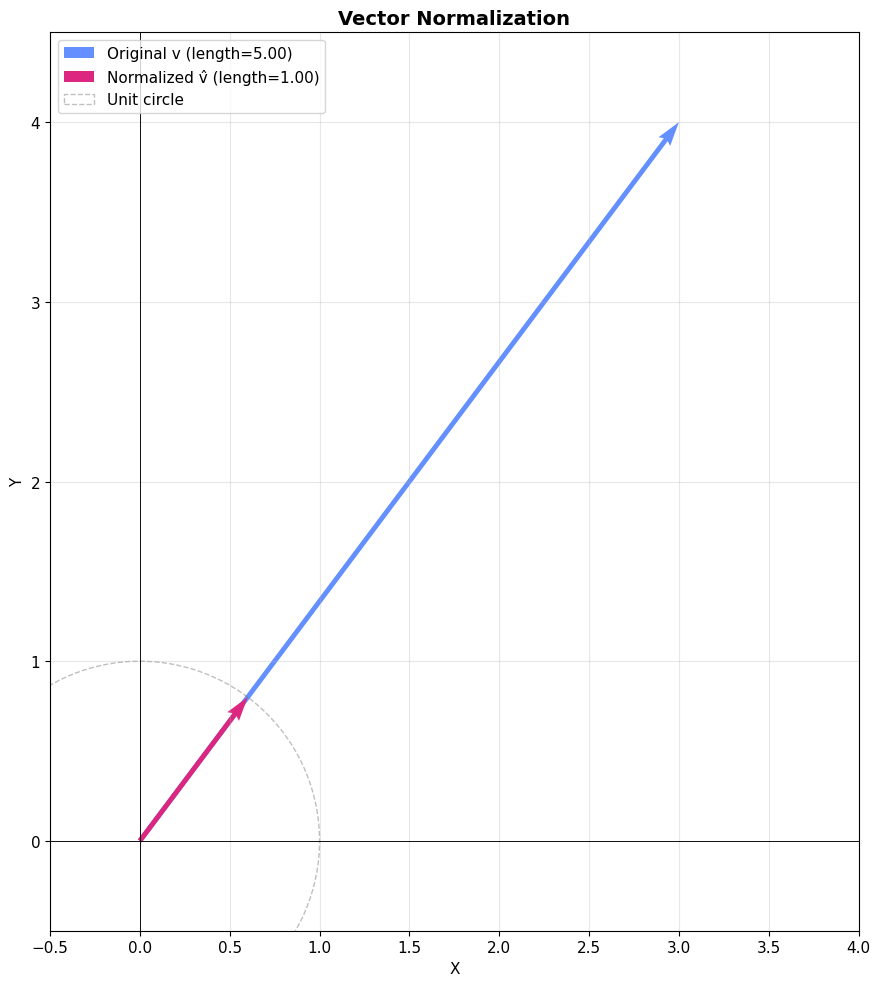

Original vector: [3. 4.]
Original length: 5.000
Normalized vector: [0.600, 0.800]
Normalized length: 1.000

💡 Notice: Both vectors point in the same direction, but v̂ has length 1


In [ ]:
# =============================================================================
# EXERCISE 1: Normalize a Vector
# =============================================================================

def normalize_vector(input_vector):
    """
    Normalize a vector to length 1.

    Parameters:
    -----------
    input_vector : ndarray, shape (n,)
        Input vector of any dimension

    Returns:
    --------
    normalized_vector : ndarray, shape (n,)
        Unit vector pointing in the same direction
    """
    # TODO: Calculate the length of the vector
    # HINT: Use np.linalg.norm()
    vector_length = ...  # YOUR CODE HERE

    # TODO: Divide the vector by its length
    # HINT: Just use regular division: input_vector / vector_length
    normalized_vector = ...  # YOUR CODE HERE

    return normalized_vector

# =============================================================================
# Test your function
# =============================================================================

# Create a test vector
test_v = np.array([3.0, 4.0])
print(f"Original vector: {test_v}")
print(f"Original length: {np.linalg.norm(test_v):.3f}")

# Normalize it
test_v_norm = normalize_vector(test_v)
print(f"\nNormalized vector: {test_v_norm}")
print(f"Normalized length: {np.linalg.norm(test_v_norm):.3f}")

# Verification checks
assert np.linalg.norm(test_v_norm) - 1.0 < 1e-10, "❌ Length should be 1!"
assert np.allclose(test_v_norm, [0.6, 0.8]), "❌ Check your calculation!"
print("\n✓ Your function works correctly!")


<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
def normalize_vector(input_vector):
    """
    Normalize a vector to length 1.
    """
    # Calculate the length
    vector_length = np.linalg.norm(input_vector)
    
    # Divide by length to normalize
    normalized_vector = input_vector / vector_length
    
    return normalized_vector
```

**Key points**:
- `np.linalg.norm()` computes the Euclidean length (L2 norm)
- Division works element-wise in NumPy
- The result always has length 1 (unit vector)

</details>

In [ ]:
# Demo: Vector normalization

def visualize_vector_normalization(v):
    """
    Visualize a vector and its normalized version.
    """
    # Calculate normalized vector
    v_norm = v / np.linalg.norm(v)

    # Create visualization
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot original vector
    plot_vector_2d(v, color='#648FFF', label=f'Original v (length={np.linalg.norm(v):.2f})', ax=ax)

    # Plot normalized vector
    plot_vector_2d(v_norm, color='#DC267F', label=f'Normalized v̂ (length={np.linalg.norm(v_norm):.2f})', ax=ax)

    # Draw unit circle for reference
    circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5, label='Unit circle')
    ax.add_patch(circle)

    ax.set_xlim(-0.5, max(4, v[0]+0.5))
    ax.set_ylim(-0.5, max(4, v[1]+0.5))
    ax.set_title('Vector Normalization', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='upper left')
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()

    print(f"Original vector: {v}")
    print(f"Original length: {np.linalg.norm(v):.3f}")
    print(f"Normalized vector: [{v_norm[0]:.3f}, {v_norm[1]:.3f}]")
    print(f"Normalized length: {np.linalg.norm(v_norm):.3f}")
    print("\n💡 Notice: Both vectors point in the same direction, but v̂ has length 1")

# Try it with different vectors
v_example = np.array([3.0, 4.0])
visualize_vector_normalization(v_example)


# Visualize your result
visualize_vector_normalization(test_v)

## 1.3 Vector Operations

We have several mathematical operations we perform on or with vectors. **Scalar multiplication** of a vector changes its length but not its direction (except for sometimes reversing by 180 degrees as we'll see in the next demo). When we multiply a vector, $\mathbf{x}$,  by a scalar, $a$, we multiply each individual component by the scalar:

$ a\mathbf{x} = \begin{bmatrix}
    a\mathbf{x}_1 \\ a\mathbf{x}_2 \\ \vdots \\ a\mathbf{x}_N
\end{bmatrix}$

You can visualize **vector addition** as the stacking of the two arrows head to tail. In essence, you are moving the second vector so its base is at the tip of the first, without changing its direction. The tip of this stacked second vector is the new added vector's tip. In order words, if you visualize two vectors as sides of a parallelogram, adding them will create a vector with the 4th vertex of that parallelogram as its tip. Numerically, this means that we add the corresponding components of each vector:


 $\mathbf{x} + \mathbf{y} = \begin{bmatrix}
           \mathbf{x}_{1} + \mathbf{y}_1 \\ \mathbf{x}_{2} + \mathbf{y}_2\\ \vdots \\ \mathbf{x}_{N} + \mathbf{y}_N
\end{bmatrix}$


We call a group of 2 or more vectors a **set of vectors**. A **linear combination** of a set of vectors is a combination of the set using scalar multiplication and vector addition. Essentially, we are multiplying each vector in the set by a scalar and then adding all the scalar multiplied vectors together: the output of this (another vector) is a linear combination of the set. More formally defined, a vector, $\mathbf{u}$, is a linear combination of a set of vectors $\mathbf{v}^1, \mathbf{v}^2, ..., \mathbf{v}^N$ with (scalar) weights $c_1, c_2, ...c_N$ if:

$\mathbf{u} = c_1\mathbf{v}^1 + c_2\mathbf{v}^2 + ... + c_n\mathbf{v}^N $


The dot product between two vectors is a scalar value computed as the sum of element-wise multiplication of vector components.

\begin{equation}
\text{Dot product of } \mathbf{x} \text{ and } \mathbf{y} = \mathbf{x} \cdot \mathbf{y} = \sum_{i=1}^{N} \mathbf{x}_i\mathbf{y}_i
\end{equation}


### Geometric Interpretation

The dot product relates to the **angle** between vectors:

$$\mathbf{a} \cdot \mathbf{b} = ||\mathbf{a}|| \cdot ||\mathbf{b}|| \cdot \cos(\theta)$$

where $\theta$ is the angle between the vectors.

### What Does the Dot Product Tell Us?

- **$\mathbf{a} \cdot \mathbf{b} > 0$**: Vectors point in similar directions (angle < 90°)
- **$\mathbf{a} \cdot \mathbf{b} = 0$**: Vectors are perpendicular (angle = 90°)
- **$\mathbf{a} \cdot \mathbf{b} < 0$**: Vectors point in opposite directions (angle > 90°)

### Behavioral Application: Direction of Movement

Imagine you want to know if an animal is moving **toward** or **away from** a target:
- Let $\mathbf{v}$ = velocity vector (direction of movement)
- Let $\mathbf{d}$ = direction vector from animal to target
- If $\mathbf{v} \cdot \mathbf{d} > 0$ → moving **toward** target
- If $\mathbf{v} \cdot \mathbf{d} < 0$ → moving **away from** target

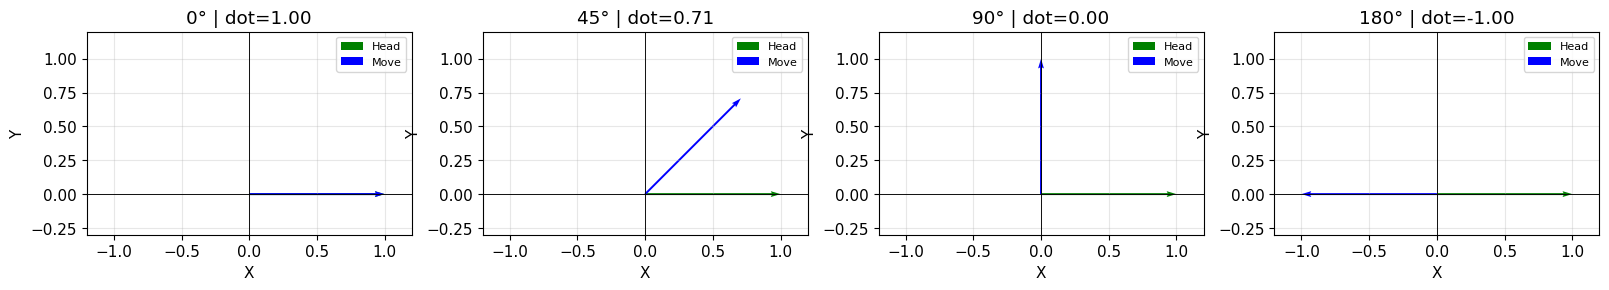

In [ ]:
# Dot product: head direction vs movement
head_dir = np.array([1, 0])
movements = [np.array([1,0]), np.array([0.707,0.707]), np.array([0,1]), np.array([-1,0])]
angles_deg = [0, 45, 90, 180]

fig, axes = plt.subplots(1,4, figsize=(16,4))
for move, angle, ax in zip(movements, angles_deg, axes):
    # TODO: use np.dot or @, calcualte the dot product between movements and head dir
    dot = None 
    plot_vector_2d(head_dir, color='green', label='Head', ax=ax)
    plot_vector_2d(move, color='blue', label='Move', ax=ax)
    ax.set_xlim(-1.2,1.2); ax.set_ylim(-0.3,1.2)
    ax.set_title(f'{angle}° | dot={dot:.2f}')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


---
### 🎯 EXERCISE 2: Calculate Angle Between Vectors

Using the dot product formula, calculate the angle between two vectors.

**Mathematical formula**:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}$$

$$\theta = \arccos\left(\frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}|| \cdot ||\mathbf{b}||}\right)$$

**Steps**:
1. Calculate the dot product of the two vectors
2. Calculate the lengths (norms) of both vectors
3. Divide dot product by the product of lengths
4. Use `np.arccos()` to get the angle in radians
5. Convert to degrees (optional)

**Hints**:
- `np.dot(a, b)` calculates the dot product
- `np.linalg.norm(v)` calculates the length
- `np.arccos(x)` gives the angle in radians
- To convert radians to degrees: `angle_degrees = angle_radians * 180 / np.pi`

In [ ]:
# =============================================================================
# EXERCISE 2: Calculate Angle Between Vectors
# =============================================================================

def angle_between_vectors(a, b, degrees=True):
    """
    Calculate the angle between two vectors.

    Parameters:
    -----------
    a, b : ndarray
        Input vectors (must have same shape)
    degrees : bool
        If True, return angle in degrees; if False, return radians

    Returns:
    --------
    angle : float
        Angle between vectors
    """
    # TODO: Calculate the dot product
    # HINT: Use np.dot(a, b)
    dot_product = ...  # YOUR CODE HERE

    # TODO: Calculate the lengths (norms) of both vectors
    # HINT: Use np.linalg.norm()
    norm_a = ...  # YOUR CODE HERE
    norm_b = ...  # YOUR CODE HERE

    # TODO: Calculate cos(theta) = (a·b) / (||a|| * ||b||)
    cos_theta = ...  # YOUR CODE HERE

    # TODO: Calculate theta using arccos
    # HINT: Use np.arccos()
    angle_radians = ...  # YOUR CODE HERE

    # Convert to degrees if requested
    if degrees:
        return angle_radians * 180 / np.pi
    else:
        return angle_radians

# =============================================================================
# Test your function
# =============================================================================

# Test case 1: Perpendicular vectors (should be 90°)
a = np.array([1, 0])
b = np.array([0, 1])
angle1 = angle_between_vectors(a, b)
print(f"Angle between {a} and {b}: {angle1:.1f}°")
assert abs(angle1 - 90) < 0.01, "❌ Should be 90 degrees!"

# Test case 2: Parallel vectors (should be 0°)
c = np.array([2, 2])
d = np.array([1, 1])
angle2 = angle_between_vectors(c, d)
print(f"Angle between {c} and {d}: {angle2:.1f}°")
assert abs(angle2 - 0) < 0.01, "❌ Should be 0 degrees!"

# Test case 3: Opposite vectors (should be 180°)
e = np.array([1, 0])
f = np.array([-1, 0])
angle3 = angle_between_vectors(e, f)
print(f"Angle between {e} and {f}: {angle3:.1f}°")
assert abs(angle3 - 180) < 0.01, "❌ Should be 180 degrees!"

print("\n✓ All tests passed! Your function works correctly!")

<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
def angle_between_vectors(a, b, degrees=True):
    """
    Calculate the angle between two vectors.
    """
    # Calculate the dot product
    dot_product = np.dot(a, b)
    
    # Calculate the norms
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    
    # Calculate cos(theta)
    cos_theta = dot_product / (norm_a * norm_b)
    
    # Calculate theta
    angle_radians = np.arccos(cos_theta)
    
    # Convert to degrees if requested
    if degrees:
        return angle_radians * 180 / np.pi
    else:
        return angle_radians
```

**Important notes**:
- The dot product divided by the product of norms gives us cos(θ)
- `np.arccos()` gives us the angle in radians [0, π]
- This angle is always between 0° and 180°

</details>

---
# Part 2: Coordinate Systems & Basis

### 2.1 dependence between vectors

The **span of a set of vectors** is the set of all possible linear combinations of those vectors. In the last demo, you saw that the vector $\mathbf{x}$ and the vector $\mathbf{y}$ spanned 2D space (${\rm I\!R}^2$). This means you can get to any point in 2D space (corresponding to vector $\mathbf{v}$ with some combination of $a$ and $b$, the scalar multiples in a linear combination of $\mathbf{x}$ and $\mathbf{y}$:

$$\mathbf{v} = a\mathbf{x} + b\mathbf{y}$$

Even more specifically, in this situation, each point in 2D space is identified by a unique and single combination of $a$ and $b$: if you know the point, you know what $a$ and $b$ are.

A set of vectors is linearly dependent if one can be written as a linear combination of the others. If this is not the case, the set of vectors is linearly independent.

## 2.1 Basis Vectors


If a set of vectors spans 2D space are linearly independent, they form a **basis** for 2D space.  This means that we can identify all points in 2D space with reference to these two vectors, instead of to the traditional x-axis and y-axis coordinates. In fact, you've been using a basis all along when you identify points by their x-axis and y-axis coordinates: the **standard basis**! In 2D space, the standard basis vectors ($\tilde{\mathbf{e}}_1$ and $\tilde{\mathbf{e}}_2$) are the unit vectors corresponding to the x and y axes:

Standard 2D basis:
$$\mathbf{e}_x = \begin{bmatrix}1\\0\end{bmatrix}, \quad \mathbf{e}_y = \begin{bmatrix}0\\1\end{bmatrix}$$

Any 2D vector can be a linear combination:
$$\mathbf{v} = v_x\mathbf{e}_x + v_y\mathbf{e}_y$$

Similarly, for 3D vectors, they can be repesented by standard 3D basis

### Key Insight, question:
Same point → different coordinates in different frames! For animal trajectorty inside the arena setup
- what is the meaningful choice of basis?
- how can it be represented?

- **Allocentric**: World-fixed
- **Egocentric**: Animal-centered


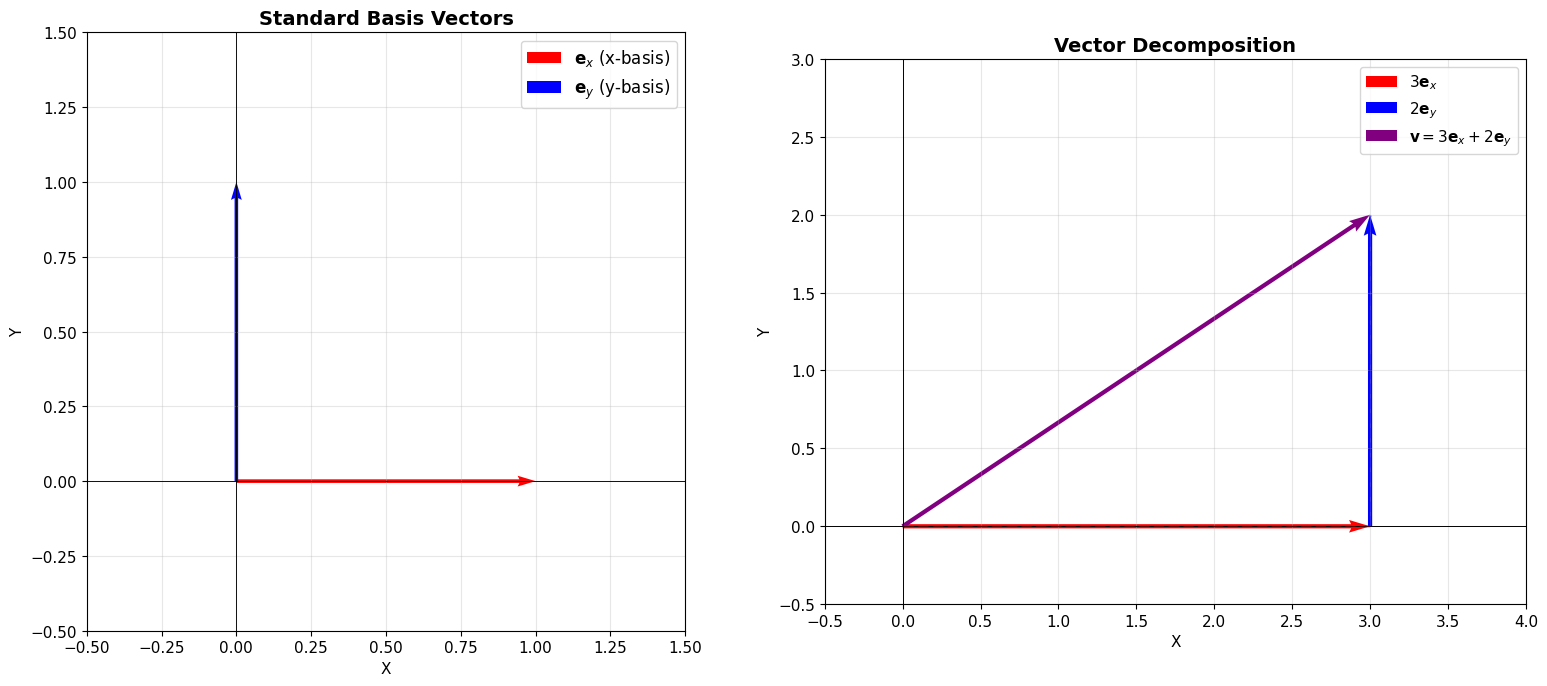

💡 Key insight:
   Any vector is just a combination of basis vectors.
   The coordinates [3, 2] tell us: go 3 units along e_x, then 2 units along e_y


In [ ]:
# Demo: Visualize basis vectors

def visualize_basis_vectors():
    """Show standard 2D basis vectors and vector decomposition."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    # Left plot: Just the basis vectors
    ex = np.array([1, 0])
    ey = np.array([0, 1])
    plot_vector_2d(ex, color='red', label='$\mathbf{e}_x$ (x-basis)', ax=ax1)
    plot_vector_2d(ey, color='blue', label='$\mathbf{e}_y$ (y-basis)', ax=ax1)
    ax1.set_xlim(-0.5, 1.5)
    ax1.set_ylim(-0.5, 1.5)
    ax1.set_title('Standard Basis Vectors', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=12)

    # Right plot: Vector decomposition
    v = np.array([3, 2])
    v_x_component = np.array([3, 0])  # 3 * e_x
    v_y_component = np.array([0, 2])  # 2 * e_y

    plot_vector_2d(v_x_component, color='red', label='$3\mathbf{e}_x$', ax=ax2)
    plot_vector_2d(v_y_component, origin=[3, 0], color='blue', label='$2\mathbf{e}_y$', ax=ax2)
    plot_vector_2d(v, color='purple', label='$\mathbf{v} = 3\mathbf{e}_x + 2\mathbf{e}_y$', ax=ax2)

    # Draw dashed lines to show decomposition
    ax2.plot([0, 3], [0, 0], 'r--', alpha=0.3, linewidth=2)
    ax2.plot([3, 3], [0, 2], 'b--', alpha=0.3, linewidth=2)

    ax2.set_xlim(-0.5, 4)
    ax2.set_ylim(-0.5, 3)
    ax2.set_title('Vector Decomposition', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11)

    plt.tight_layout()
    plt.show()

    print("💡 Key insight:")
    print("   Any vector is just a combination of basis vectors.")
    print("   The coordinates [3, 2] tell us: go 3 units along e_x, then 2 units along e_y")

visualize_basis_vectors()

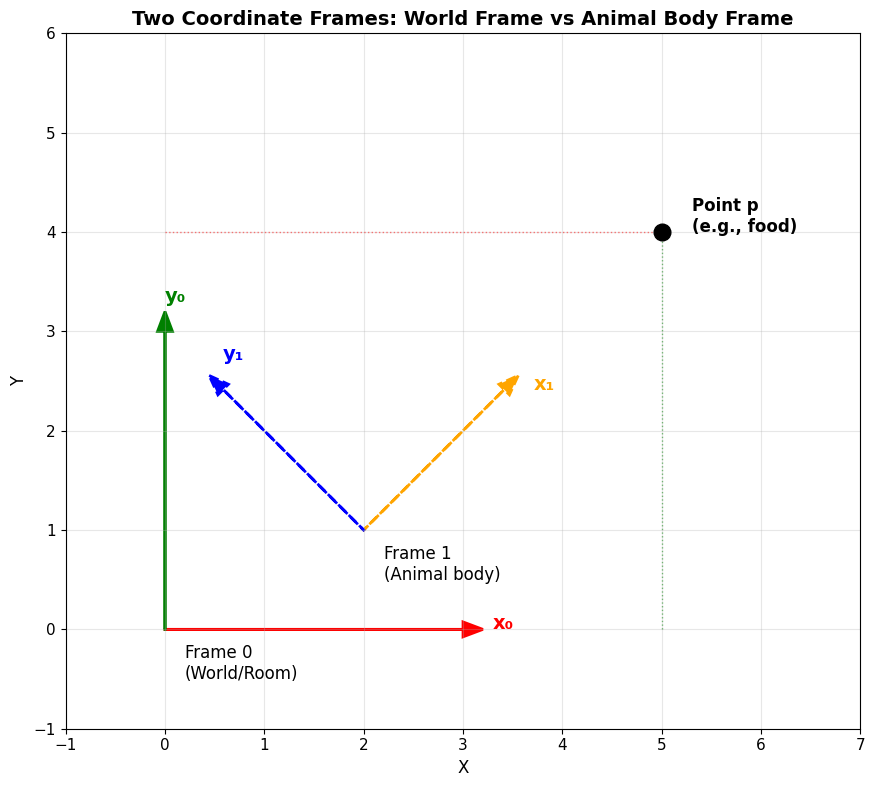


🔑 KEY INSIGHT:
The black point is at the SAME physical location, but has different coordinates
depending on whether you measure from Frame 0 or Frame 1!


In [ ]:
def plot_2d_frames():
    """Visualize two coordinate frames and a point"""
    fig, ax = plt.subplots(figsize=(10, 8))

    # Frame 0 (reference frame - like the room)
    ax.arrow(0, 0, 3, 0, head_width=0.15, head_length=0.2, fc='red', ec='red', linewidth=2)
    ax.arrow(0, 0, 0, 3, head_width=0.15, head_length=0.2, fc='green', ec='green', linewidth=2)
    ax.text(3.3, 0, 'x₀', fontsize=14, fontweight='bold', color='red')
    ax.text(0, 3.3, 'y₀', fontsize=14, fontweight='bold', color='green')
    ax.text(0.2, -0.5, 'Frame 0\n(World/Room)', fontsize=12, ha='left')

    # Frame 1 (rotated frame - like the animal's body)
    angle = np.pi / 4  # 45 degrees
    origin1 = np.array([2, 1])

    # Rotated axes
    x1_vec = 2 * np.array([np.cos(angle), np.sin(angle)])
    y1_vec = 2 * np.array([-np.sin(angle), np.cos(angle)])

    ax.arrow(origin1[0], origin1[1], x1_vec[0], x1_vec[1],
             head_width=0.15, head_length=0.2, fc='orange', ec='orange', linewidth=2, linestyle='--')
    ax.arrow(origin1[0], origin1[1], y1_vec[0], y1_vec[1],
             head_width=0.15, head_length=0.2, fc='blue', ec='blue', linewidth=2, linestyle='--')

    ax.text(origin1[0] + x1_vec[0] + 0.3, origin1[1] + x1_vec[1], 'x₁',
            fontsize=14, fontweight='bold', color='orange')
    ax.text(origin1[0] + y1_vec[0], origin1[1] + y1_vec[1] + 0.3, 'y₁',
            fontsize=14, fontweight='bold', color='blue')
    ax.text(origin1[0] + 0.2, origin1[1] - 0.5, 'Frame 1\n(Animal body)', fontsize=12, ha='left')

    # A point in space (e.g., food location)
    point = np.array([5, 4])
    ax.plot(point[0], point[1], 'ko', markersize=12, zorder=5)
    ax.text(point[0] + 0.3, point[1], 'Point p\n(e.g., food)', fontsize=12, fontweight='bold')

    # Draw lines to show coordinates in each frame
    ax.plot([0, point[0]], [point[1], point[1]], 'r:', linewidth=1, alpha=0.5)
    ax.plot([point[0], point[0]], [0, point[1]], 'g:', linewidth=1, alpha=0.5)

    ax.set_xlim(-1, 7)
    ax.set_ylim(-1, 6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_title('Two Coordinate Frames: World Frame vs Animal Body Frame', fontsize=14, fontweight='bold')

    plt.tight_layout()
    return fig

plot_2d_frames()
plt.show()

print("\n🔑 KEY INSIGHT:")
print("The black point is at the SAME physical location, but has different coordinates")
print("depending on whether you measure from Frame 0 or Frame 1!")

---

# Part 3: Matrices as Transformations

## 3.1 Matrices and Vector Multiplication

### 1. Conceptualizing Matrix-Vector Multiplication

When we multiply a $2 \times 2$ matrix $M$ by a 2D vector $\vec{v}$, we are effectively transforming that vector into a new space.

$$M\vec{v} = \begin{bmatrix} a & b \\ c & d \end{bmatrix} \begin{bmatrix} x \\ y \end{bmatrix} = x \begin{bmatrix} a \\ c \end{bmatrix} + y \begin{bmatrix} b \\ d \end{bmatrix} = \vec{v}_{new}$$

> **Key Insight:** The columns of the matrix tell you exactly where the original **basis vectors** (the unit "steps" in $X$ and $Y$) land after the transformation.

---

### 🎯 EXERCISE 3: Calculate tranformation matrix

To build an intuition for how tracking data is manipulated, try to solve these two transformation problems.

#### Task 1: Single Vector Transformation

**Goal:** Find a matrix $M$ that transforms the vector $\vec{v}_{start} = \begin{bmatrix} 0 \\ 1 \end{bmatrix}$ to the vector $\vec{v}_{end} = \begin{bmatrix} 0 \\ -1 \end{bmatrix}$.

* **Is the solution unique?** * *Hint:* Think about the different ways to move that point. Could you rotate it? Reflect it? Scale it?.


In [ ]:
# Task1 find the matrix that performs the transformation make v_start = [0, 1] into v_target = [0, -1]
# Starting vector v = [0, 1]
v_start = np.array([0, 1])
v_target = np.array([0, -1])

# The transformation matrix M that maps v_start to v_target is:
# M @ v_start = v_target
# So we solve for M by computing the outer product of v_target and the inverse of v_start
# Since v_start is [0, 1], its inverse is not defined in the usual sense.
# However, we can construct a matrix that maps [0, 1] to [0, -1] directly:
## TODO: fill in the correct values for M
# M = ..

# Verify the transformation
# print(f"Rotation Result: {M @ v_start}")


<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python


# Solution A: Rotation by 180 degrees
M_rot = np.array([[-1,  0],
                  [ 0, -1]])

# Solution B: Reflection across the X-axis
M_ref = np.array([[ 1,  0],
                  [ 0, -1]])

# Solution C: Vertical Scaling by -1
M_scale = np.array([[ 1,  0],
                    [ 0, -1]])

```
**Important notes**:
</details>



#### Task 2: Basis Transformation (The "Rigid Body" Problem)

**Goal:** In behavioral tracking, we often track multiple body parts (like head and tail) to define a coordinate system.

How do we generate a matrix that transforms the original basis set $\begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$ to a new orientation $\begin{bmatrix} 0 & 1 \\ -1 & 0 \end{bmatrix}$?

* **Is the solution unique?**
* *Hint:* Once you define where **two** non-parallel vectors land, the transformation for the entire 2D space is locked in (it is a unique linear transformation).

In [ ]:
v_start = np.array([[0, 1],
                    [1, 0]])
v_target = np.array([[0, -1],
                    [1, 0]])
## TODO: fill in the correct values for M
# The transformation matrix M that maps v_start to v_target is:
# M @ v_start = v_target
# We can solve for M by computing the product of v_target and the inverse of v_start
# Since v_start is a permutation of the identity matrix, its inverse is simply its transpose


<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python

# click for solution
v_start = np.array([[0, 1],
                    [1, 0]])
v_target = np.array([[0, -1],
                    [1, 0]])
M = v_target @ np.linalg.inv(v_start)


```
**Important notes**:
</details>

--
## 3.2 The Condition for a Unique Solution: Full Rank
In the previous exercise, we manually guessed the matrix $M$ that transformed our "Begin" basis to our "Target" basis. In real behavioral tracking, we need a mathematical way to **solve** for $M$ automatically.

If we have a starting configuration (a matrix of body parts) $B$ and a target configuration $T$, we are looking for a transformation matrix $M$ such that:

$$M \cdot B = T$$

To find $M$, we need to "isolate" it. We do this by multiplying both sides by the **inverse** of $B$:

$$M = T \cdot B^{-1}$$

### The "Information" Rule:

We can only calculate $B^{-1}$ if the matrix $B$ is **Full Rank**.

* **Full Rank:** Your tracking points are not "squashed." For example, if you track a Head and a Tail, they cannot be at the same exact coordinate.


* **Rank Deficient:** If your points collapse into a single line or point (the **Null Space**), you have lost a dimension of information. In this state, the transformation is not unique, and you cannot mathematically "undo" the movement.



---

### Gallery of Transformations

Once we have a valid transformation matrix $M$, we can apply it to any behavioral data. These matrices can be applied in **sequence** (Matrix Composition) to perform complex movements.

Common transformations in ethology include:

| Transformation | Matrix Representation ($M$) | Effect |
| --- | --- | --- |
| **Scaling** | $\begin{bmatrix} s_x & 0 \\ 0 & s_y \end{bmatrix}$ | Changes the size of the animal or arena.|

| **Reflection (X)** | $\begin{bmatrix} -1 & 0 \\ 0 & 1 \end{bmatrix}$ | Flips the data horizontally (mirrors the camera).|

| **Reflection (Y)** | $\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix}$ | Flips the data vertically. |

| **Rotation ($\theta$)** | $\begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$ | Changes the animal's heading angle. |

### 🎯 EXERCISE 4:  Visualizing Rank and Transformations
The following code demonstrates how to solve for $M$ using the inverse and visualizes different types of behavioral "re-scaling."



In [ ]:

# 2. Define standard transformations for visualization
# Scaling (1.5x larger)
## TODO: fill in the correct values for M_scale
# M_scale =  ...
# # Flip X-axis (Left-Right swap)
# M_flip_x =  ...
# # Flip Y-axis (Up-Down swap)
# M_flip_y =  ...

# Define a 'Mouse' shape (Body points)
mouse = np.array([[0, 0.5, 0.2, -0.2, ],  # X coordinates
                  [0, 1.0, 0.8,  0.8,]]) # Y coordinates

# Apply Transformations
scaled_mouse = M_scale @ mouse
flipped_x = M_flip_x @ mouse
flipped_y = M_flip_y @ mouse

# Visualization
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].plot(mouse[0], mouse[1], 'b-o'); ax[0].set_title("Original Mouse")
ax[1].plot(scaled_mouse[0], scaled_mouse[1], 'r-o'); ax[1].set_title("Scaled (1.5x)")
ax[2].plot(flipped_x[0], flipped_x[1], 'g-o'); ax[2].set_title("Flipped X (L/R)")
ax[3].plot(flipped_y[0], flipped_y[1], 'm-o'); ax[3].set_title("Flipped Y (U/D)")

for a in ax:
    a.set_xlim(-2, 2); a.set_ylim(-2, 2); a.grid(True); a.set_aspect('equal')
plt.show()

## Demo: Rotation matrix in 2D
def rotation_matrix_2d(theta):
    ## TODO: fill in the correct values for the rotation matrix
    # c = ..
    # s = ...
    return np.array([[c, -s], [s, c]])



# Demo: Rotate basis vectors
angles = [0, np.pi/6, np.pi/4, np.pi/2]
names = ['0°', '30°', '45°', '90°']

fig, axes = plt.subplots(1,4, figsize=(16,4))
for theta, name, ax in zip(angles, names, axes):
    R = rotation_matrix_2d(theta)
    ex_rot = R @ np.array([1,0])
    ey_rot = R @ np.array([0,1])

    plot_vector_2d([1,0], color='red', label='$e_x$', ax=ax)
    plot_vector_2d([0,1], color='blue', label='$e_y$', ax=ax)
    plot_vector_2d(ex_rot, color='darkred', label='rotated', ax=ax)
    plot_vector_2d(ey_rot, color='darkblue', ax=ax)
    ax.set_xlim(-0.2,1.2); ax.set_ylim(-0.2,1.2)
    ax.set_title(f'Rotate {name}')
    if theta==0: ax.legend(fontsize=8)
plt.tight_layout(); plt.show()



<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python

M_scale = np.array([[1.5, 0],
                    [0, 1.5]])
M_flip_x = np.array([[-1, 0],
                     [0, 1]])
M_flip_y = np.array([[1, 0],
                     [0, -1]])



def rotation_matrix_2d(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s], [s, c]])

```
**Important notes**:
</details>



## 3.3 Exercise 2: Compose Transformations

**Task**: Calculate final orientation after sequence of turns

**Key**: $\mathbf{R}_{total} = \mathbf{R}_3 \mathbf{R}_2 \mathbf{R}_1$  
⚠️ Order matters! Matrix multiplication is NOT commutative


In [ ]:
# =============================================================================
# EXERCISE 4: Compose Multiple Rotations
# =============================================================================

# Define the three turns (in radians)
turn1 = 30 * np.pi / 180   # 30° counterclockwise
turn2 = 45 * np.pi / 180   # 45° counterclockwise
turn3 = -60 * np.pi / 180  # 60° clockwise (negative)

print("Turn sequence:")
print(f"  Turn 1: {30}° counterclockwise")
print(f"  Turn 2: {45}° counterclockwise")
print(f"  Turn 3: {-60}° (60° clockwise)")
print(f"  Net turn should be: {30 + 45 - 60} = {15}°\n")

# TODO: Create rotation matrices for each turn
# HINT: Use rotation_matrix_2d() function you wrote earlier
R1 = ...  # YOUR CODE HERE
R2 = ...  # YOUR CODE HERE
R3 = ...  # YOUR CODE HERE

# TODO: Compose the rotations
# HINT: R_total = R3 @ R2 @ R1 (apply R1 first, then R2, then R3)
R_total = ...  # YOUR CODE HERE

# Verify by comparing with direct rotation
net_angle = turn1 + turn2 + turn3
R_direct = rotation_matrix_2d(net_angle)

# Check if they're equal
assert np.allclose(R_total, R_direct), "❌ Composition doesn't match direct rotation!"
print("✓ Composition matches direct rotation!\n")

# =============================================================================
# Visualization
# =============================================================================

# Start with a vector pointing right
initial = np.array([1, 0])

# Apply rotations one by one
after_turn1 = R1 @ initial
after_turn2 = R2 @ after_turn1
after_turn3 = R3 @ after_turn2

# Plot the sequence
fig, ax = plt.subplots(figsize=(10, 10))

# Draw unit circle for reference
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.3)
ax.add_patch(circle)

# Plot each orientation
plot_vector_2d(initial, color='lightgray', label='Initial (0°)', ax=ax)
plot_vector_2d(after_turn1, color='lightblue', label=f'After turn 1 (30°)', ax=ax)
plot_vector_2d(after_turn2, color='blue', label=f'After turn 2 (75°)', ax=ax)
plot_vector_2d(after_turn3, color='darkblue', label=f'Final (15°)', ax=ax)

ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_title('Sequence of Rotations', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

print(f"\nFinal angle: {net_angle * 180 / np.pi:.1f}°")
print("\n💡 Notice: The net rotation is just the sum of individual rotations!")
print("   But the rotation matrices compose through multiplication.")

Turn sequence:
  Turn 1: 30° counterclockwise
  Turn 2: 45° counterclockwise
  Turn 3: -60° (60° clockwise)
  Net turn should be: 15 = 15°



NameError: name 'rotation_matrix_2d' is not defined

<details>
<summary><b>💡 Click here to see the solution</b></summary>

```python
# Create rotation matrices
R1 = rotation_matrix_2d(turn1)
R2 = rotation_matrix_2d(turn2)
R3 = rotation_matrix_2d(turn3)

# Compose rotations (right to left: first R1, then R2, then R3)
R_total = R3 @ R2 @ R1
```

**Why does this work?**

When we apply $\mathbf{R}_{total} \mathbf{v}$:
- First, $\mathbf{R}_1$ rotates $\mathbf{v}$
- Then $\mathbf{R}_2$ rotates that result
- Finally $\mathbf{R}_3$ rotates that result

**Important note**: For 2D rotations around the same point (origin), angles add:
$$\theta_{total} = \theta_1 + \theta_2 + \theta_3$$

So we could also just calculate the total angle and create one matrix. But:
1. Matrix composition is more general (works for 3D, different centers, etc.)
2. It's conceptually clearer for tracking sequences
3. It's what actually happens in the computation

</details>

---
# Part 4: 3D Transformations (Preview)

## 4.1 3D Rotations

Around each axis:
$$\mathbf{R}_z(\theta) = \begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}$$

$$\mathbf{R}_x(\theta) = \begin{bmatrix}1&0&0\\0&\cos\theta&-\sin\theta\\0&\sin\theta&\cos\theta\end{bmatrix}$$

$$\mathbf{R}_y(\theta) = \begin{bmatrix}\cos\theta&0&\sin\theta\\0&1&0\\-\sin\theta&0&\cos\theta\end{bmatrix}$$

Used for full 3D pose tracking!


In [ ]:
def rotation_matrix_3d(axis, theta):
    c, s = np.cos(theta), np.sin(theta)
    if axis=='x': return np.array([[1,0,0],[0,c,-s],[0,s,c]])
    elif axis=='y': return np.array([[c,0,s],[0,1,0],[-s,0,c]])
    elif axis=='z': return np.array([[c,-s,0],[s,c,0],[0,0,1]])

v = np.array([1,0,0])
R_z = rotation_matrix_3d('z', np.pi/2)
v_rot = R_z @ v
print(f"Original: {v}")
print(f"After 90° around z: {v_rot}")
print("(Should point along y-axis)")


Original: [1 0 0]
After 90° around z: [6.123234e-17 1.000000e+00 0.000000e+00]
(Should point along y-axis)


## 🎯 Excercise
why the rotaion matrix is like 

$$\mathbf{R}_z(\theta) = \begin{bmatrix}\cos\theta&-\sin\theta&0\\\sin\theta&\cos\theta&0\\0&0&1\end{bmatrix}$$
?
Can you prove it?

# 💡 Hints

**Hint 1:** A point at angle $\phi$ and distance $r$ has coordinates $x = r\cos\phi$, $y = r\sin\phi$. After rotating by $\theta$, what is the new angle?

**Hint 2:** Expand $\cos(\phi + \theta)$ and $\sin(\phi + \theta)$ using angle addition formulas. Do you see $x$ and $y$ hiding inside?

**Hint 3:** What happens to $z$ when rotating *around* the Z-axis?

**Hint 4:** Once you have $x', y', z'$ as combinations of $x, y, z$ — pack them into a matrix!

---
# Summary & Key Takeaways

## What We Learned Today

### 1. Vectors (Part 1)
- **Vectors** represent positions, velocities, and directions
- **Length (norm)**: $||\mathbf{v}|| = \sqrt{\sum v_i^2}$ measures magnitude
- **Normalization**: Convert to unit vector (length 1) to isolate direction
- **Dot product**: Reveals angle between vectors, direction similarity

### 2. Coordinate Systems (Part 2)
- Same physical point → different coordinates in different frames
- **World frame** (allocentric): Camera/arena perspective
- **Body frame** (egocentric): Animal's perspective
- **Basis vectors** define coordinate axes

### 3. Transformations (Part 3)
- **Rotation matrices** transform coordinates between frames
- 2D rotation by $\theta$: $\mathbf{R}(\theta) = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}$
- **Matrix composition**: $\mathbf{R}_{total} = \mathbf{R}_3 \mathbf{R}_2 \mathbf{R}_1$ (right-to-left order)
- Order matters! Matrix multiplication is not commutative

### 4. 3D Rotations (Part 4)
- Extend to 3D with axis-specific rotation matrices

---

## Connection to Behavioral Analysis

These mathematical tools are the **foundation** for everything we'll do this week:

### Day 2: DeepLabCut
- Outputs: Body part positions

### Day 3: Trajectories
- Trajectory segmentation based on different features
- Change-point detection in movement

### Day 4: Behavioral States
- Interpret behavior based on markers.
- PCA decomposes posture into principal components (eigenvectors) and clustering
- Moseq if time allowed

### Day 5: Integration
- Transition matrices govern behavioral sequences
- Navigation strategies use angles and distances
- HMMs model hidden states

---

---

## Additional Resources

### Video Tutorials
- [3Blue1Brown: Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) ⭐ **Highly recommended!**
  - Visual, intuitive explanations of vectors, matrices, and transformations

### Documentation
- [NumPy Linear Algebra](https://numpy.org/doc/stable/reference/routines.linalg.html)
  - Reference for `np.linalg` functions

### Course Materials
- [Neuromatch Academy Linear Algebra Tutorial](https://colab.research.google.com/github/NeuromatchAcademy/precourse/blob/main/tutorials/W0D3_LinearAlgebra/instructor/W0D3_Tutorial1.ipynb)

---

## Reflection Questions

Before moving to the afternoon session, think about:

1. **Why would we normalize velocity vectors** when analyzing movement patterns?
   <details>
   <summary>Hint</summary>
   We care about direction of movement, not speed.
   </details>

2. **When would animal-centered coordinates be more useful than world coordinates?**

---

## What's Next?

**This afternoon**: Apply these concepts to real behavioral data!
- Understang the 3D tracking feature in animal.
- Transform between coordinate systems

**Tomorrow (Day 2)**: DeepLabCut for pose estimation
- How tracking systems work
- Quality checks and filtering

---

**Great work today!** 🎉

Take a break. When you come back, we'll put these tools to work analyzing real animal behavior!